In [2]:
from atomsmltr.simulation import RK4, Euler, Euler_spontem, VelocityVerlet, ScipyIVP_3D, Configuration
from atomsmltr.atoms import Ytterbium
from atomsmltr.environment.lasers import PlaneWaveLaserBeam

import matplotlib.pyplot as plt
import numpy as np
import scipy.constants as csts

In [3]:
config = Configuration(atom=Ytterbium())
main = config.atom.trans["main"]
main.print_info()

l399 = {
    "wavelength": 399e-9,
    "waist": 22e-3,
    "power": 100e-3 / 6,
    "waist_position": (0, 0, 0),
}

for d in [(0,0,1), (0,0,-1), (0,1,0), (0,-1,0), (1,0,0), (-1,0,0)]:
    laser = PlaneWaveLaserBeam(direction=d)
    laser.set_power_from_I(0.5 * main.Isat)
    config += laser

for laser in config.list_lasers():
    config.add_atomlight_coupling(laser=laser, transition="main", detuning=-0.5*main.Gamma)

────────
| main |
────────
. Parameters :
  ├── λ : 398.91 nm
  ├── Γ : 2π × 2.89e+07 Hz
  ├── Isat : 59.51 mw/cm²
  ├── Doppler temp. : 6.93e-04 K
  └── lande factor g : 1.035




In [25]:
u0 = np.array([0,0,0,0,0,30])
t = np.linspace(0, 0.002, 10_000)
results = {}

In [26]:
sim = RK4(config)
res = sim.integrate(u0, t)
results["RK4"] = res
ref = res
%timeit res = sim.integrate(u0, t)

8.12 s ± 498 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [27]:
sim = ScipyIVP_3D(config)
res = sim.integrate(u0, t)
results["Scipy_radau"] = res
%timeit res = sim.integrate(u0, t)

69.5 ms ± 1.49 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [28]:
sim = ScipyIVP_3D(config, method="RK45")
res = sim.integrate(u0, t)
results["Scipy_RK45"] = res
%timeit res = sim.integrate(u0, t)

38.7 ms ± 1.21 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [29]:
sim = ScipyIVP_3D(config, method="RK23")
res = sim.integrate(u0, t)
results["Scipy_RK23"] = res
%timeit res = sim.integrate(u0, t)

32.2 ms ± 1.19 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [30]:
sim = VelocityVerlet(config)
res = sim.integrate(u0, t)
results["VelocityVerlet"] = res
%timeit res = sim.integrate(u0, t)

4 s ± 185 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [31]:
sim = Euler(config)
res = sim.integrate(u0, t)
results["Euler"] = res
%timeit res = sim.integrate(u0, t)

2 s ± 69.1 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [32]:
sim = Euler_spontem(config, enable_fluct=False)
res = sim.integrate(u0, t)
results["Euler_spontem - no fluct"] = res
%timeit res = sim.integrate(u0, t)

1.99 s ± 88 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [33]:
# sim = Euler_spontem(config, enable_fluct=True)
# res = sim.integrate(u0, t)
# results["Euler_spontem - fluct"] = res
# %timeit res = sim.integrate(u0, t)

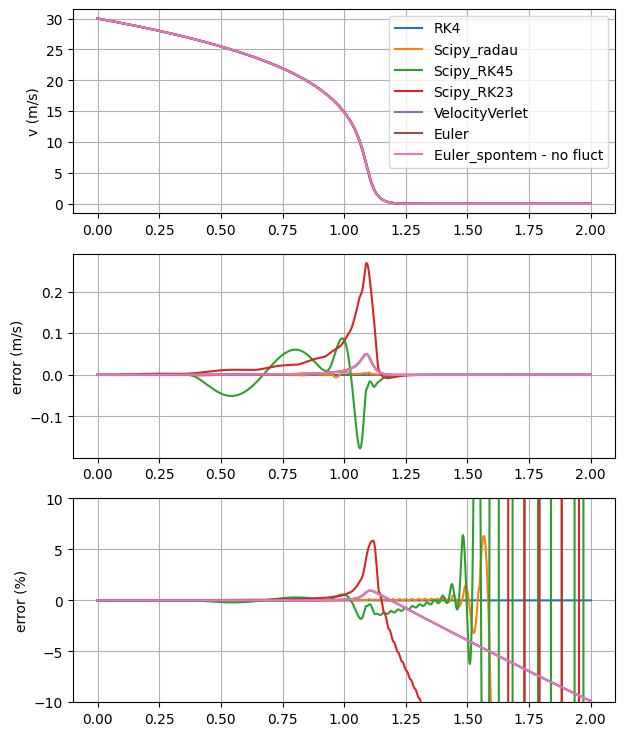

In [34]:
fig, ax = plt.subplots(3, 1, figsize=(7,9))
for label, res in results.items():
    ax[0].plot(res.t * 1e3, res.y[5,:], label=label)
    ax[1].plot(res.t * 1e3, (res.y[5,:] - ref.y[5,:]), label=label)
    ax[2].plot(res.t * 1e3, 100 * (res.y[5,:] - ref.y[5,:]) / ref.y[5,:], label=label)

ax[0].set_ylabel("v (m/s)")
ax[0].legend()
ax[1].set_ylabel("error (m/s)")
ax[2].set_ylabel("error (%)")
ax[2].set_ylim(-10,10)
for cax in ax:
    cax.grid()
plt.show()